# Minimal SAR Flood Segmentation

A stripped-down, from-scratch version of the InferSAR pipeline: data → model → train → evaluate → visualize, all in one place with no CLI flags, config files, or checkpoint bookkeeping.

Everything here is a plain variable you can change and re-run. Use this to test ideas quickly (loss functions, thresholds, augmentation, backbones) before deciding whether they're worth porting into the real pipeline.

Uses the same real data as InferSAR (`data/4final/dataset/`): 2-band VV/VH tiles already in dB, masks with `-1`=invalid, `0`=dry, `1`=water.

In [1]:
import csv
import random
from pathlib import Path

import json
import numpy as np
import rasterio
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

device: mps


## 1. Data

Point straight at the real tiles. `MAX_SAMPLES` caps dataset size for fast iteration — set to `None` to use everything (252 train / 89 val tiles).

In [13]:
ROOT = Path("data/4final/dataset")
IMAGES_DIR = ROOT / "S1Hand"
LABELS_DIR = ROOT / "LabelHand"
TRAIN_CSV = ROOT / "flood_train_data.csv"
VAL_CSV = ROOT / "flood_valid_data.csv"
TEST_CSV = ROOT / "flood_test_data.csv"

STATS = json.loads(Path("configs/global_minmax_INPUT/global_minmax.json").read_text())
print(STATS)

MAX_SAMPLES = None  # None = use all tiles

{'db_min': -60.96, 'db_max': 11.0, 'vv_mean': -10.44, 'vv_std': 4.17, 'vh_mean': -17.31, 'vh_std': 4.88}


In [3]:
def read_pairs(csv_path, limit=None):
    with open(csv_path) as f:
        rows = [row for row in csv.reader(f) if row]
    if limit:
        rows = rows[:limit]
    return rows


class FloodTiles(Dataset):
    """Minimal dataset: load VV/VH + mask, normalize, done. No augmentation, no diagnostics."""

    def __init__(self, pairs, augment=False):
        self.pairs = pairs
        self.augment = augment

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_name, mask_name = self.pairs[idx]

        with rasterio.open(IMAGES_DIR / img_name) as src:
            vv = src.read(1).astype(np.float32)
            vh = src.read(2).astype(np.float32)
        with rasterio.open(LABELS_DIR / mask_name) as src:
            raw_mask = src.read(1).astype(np.int64)

        vv = np.clip(vv, STATS["db_min"], STATS["db_max"])
        vh = np.clip(vh, STATS["db_min"], STATS["db_max"])
        vv = (vv - STATS["vv_mean"]) / STATS["vv_std"]
        vh = (vh - STATS["vh_mean"]) / STATS["vh_std"]
        # np.clip doesn't sanitize NaN; ~9% of tiles have NaN pixels that otherwise poison whole batches
        np.nan_to_num(vv, nan=0.0, posinf=0.0, neginf=0.0, copy=False)
        np.nan_to_num(vh, nan=0.0, posinf=0.0, neginf=0.0, copy=False)

        img = torch.from_numpy(np.stack([vv, vh], axis=0))
        valid = torch.from_numpy((raw_mask != -1).astype(np.float32)).unsqueeze(0)
        mask = torch.from_numpy(np.where(raw_mask == -1, 0, raw_mask).astype(np.float32)).unsqueeze(0)

        if self.augment:
            if random.random() < 0.5:
                img, mask, valid = (torch.flip(t, dims=[-1]) for t in (img, mask, valid))
            if random.random() < 0.5:
                img, mask, valid = (torch.flip(t, dims=[-2]) for t in (img, mask, valid))

        return img, mask, valid

In [14]:
train_ds = FloodTiles(read_pairs(TRAIN_CSV, MAX_SAMPLES), augment=True)
val_ds = FloodTiles(read_pairs(VAL_CSV, MAX_SAMPLES))
test_ds = FloodTiles(read_pairs(TEST_CSV, MAX_SAMPLES))

train_dl = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
val_dl = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=0)
test_dl = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=0)

print(f"train tiles: {len(train_ds)}, val tiles: {len(val_ds)}, test tiles: {len(test_ds)}")

img, mask, valid = train_ds[0]
print("img shape:", img.shape, "mask shape:", mask.shape)

train tiles: 252, val tiles: 89, test tiles: 15
img shape: torch.Size([2, 512, 512]) mask shape: torch.Size([1, 512, 512])


## 2. Model

Same architecture as the production checkpoint (resnet34 U-Net, 2-channel input) so results are comparable — swap `encoder_name` here to try something else.

In [16]:
model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", in_channels=2, classes=1).to(device)
# model = smp.Unet(encoder_name="mit_b0", encoder_weights="imagenet", in_channels=2, classes=1).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"{n_params / 1e6:.1f}M params")

24.4M params


## 3. Train

Plain PyTorch loop — no Lightning, no callbacks. BCE + Dice loss, masked by `valid` so nodata pixels don't contribute.

In [17]:
def bce_dice_loss(logits, mask, valid, bce_weight=0.35, eps=1e-6):
    bce = nn.functional.binary_cross_entropy_with_logits(logits, mask, reduction="none")
    bce = (bce * valid).sum() / valid.sum().clamp(min=1)

    probs = torch.sigmoid(logits) * valid
    mask_v = mask * valid
    intersection = (probs * mask_v).sum()
    dice = 1 - (2 * intersection + eps) / (probs.sum() + mask_v.sum() + eps)

    return bce_weight * bce + (1 - bce_weight) * dice


optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
EPOCHS = 20

In [18]:
def run_epoch(loader, train):
    model.train(train)
    total_loss = 0.0
    for img, mask, valid in loader:
        img, mask, valid = img.to(device), mask.to(device), valid.to(device)
        with torch.set_grad_enabled(train):
            logits = model(img)
            loss = bce_dice_loss(logits, mask, valid)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * img.size(0)
    return total_loss / len(loader.dataset)


for epoch in range(EPOCHS):
    train_loss = run_epoch(train_dl, train=True)
    val_loss = run_epoch(val_dl, train=False)
    print(f"epoch {epoch+1:02d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

epoch 01  train_loss=0.6134  val_loss=0.5193
epoch 02  train_loss=0.5220  val_loss=0.4033
epoch 03  train_loss=0.4781  val_loss=0.3474
epoch 04  train_loss=0.4275  val_loss=0.3533
epoch 05  train_loss=0.3927  val_loss=0.3094
epoch 06  train_loss=0.4001  val_loss=0.3192
epoch 07  train_loss=0.3650  val_loss=0.2923
epoch 08  train_loss=0.3414  val_loss=0.2930
epoch 09  train_loss=0.3572  val_loss=0.3198
epoch 10  train_loss=0.3263  val_loss=0.2634
epoch 11  train_loss=0.2837  val_loss=0.2840
epoch 12  train_loss=0.3220  val_loss=0.2801
epoch 13  train_loss=0.2901  val_loss=0.2547
epoch 14  train_loss=0.3041  val_loss=0.3011
epoch 15  train_loss=0.3222  val_loss=0.2651
epoch 16  train_loss=0.2978  val_loss=0.2545
epoch 17  train_loss=0.2752  val_loss=0.2369
epoch 18  train_loss=0.2754  val_loss=0.2405
epoch 19  train_loss=0.2533  val_loss=0.2620
epoch 20  train_loss=0.2732  val_loss=0.2749


## 4. Evaluate

IoU/F1 at a chosen threshold, computed the same way as the production pipeline (excluding invalid pixels).

In [8]:
@torch.no_grad()
def evaluate(loader, threshold=0.5):
    model.eval()
    tp = fp = fn = 0
    for img, mask, valid in loader:
        img, mask, valid = img.to(device), mask.to(device), valid.to(device)
        pred = (torch.sigmoid(model(img)) > threshold).float()
        v = valid.bool()
        pred_v, mask_v = pred[v], mask[v]
        tp += ((pred_v == 1) & (mask_v == 1)).sum().item()
        fp += ((pred_v == 1) & (mask_v == 0)).sum().item()
        fn += ((pred_v == 0) & (mask_v == 1)).sum().item()
    iou = tp / (tp + fp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    return {"iou": iou, "f1": f1, "precision": precision, "recall": recall}

In [19]:
print(evaluate(val_dl, threshold=0.5))
print("threshold=0.1:", evaluate(val_dl, threshold=0.1))
print("threshold=0.01:", evaluate(val_dl, threshold=0.01))

{'iou': 0.6030522465814546, 'f1': 0.7523800224637136, 'precision': 0.8696817553988501, 'recall': 0.662960620842371}
threshold=0.1: {'iou': 0.6115226837643175, 'f1': 0.7589377250578553, 'precision': 0.8029433195533512, 'recall': 0.719505006468967}
threshold=0.01: {'iou': 0.45286229326732386, 'f1': 0.623407038657413, 'precision': 0.48864958472295883, 'recall': 0.8607922309791012}


### Test set (Bolivia)

In [ ]:
print("test (threshold=0.5):", {k: round(v, 3) for k, v in evaluate(test_dl, threshold=0.5).items()})
print("test (threshold=0.3):", {k: round(v, 3) for k, v in evaluate(test_dl, threshold=0.3).items()})
print("test (threshold=0.1):", {k: round(v, 3) for k, v in evaluate(test_dl, threshold=0.1).items()})
print("test (threshold=0.05):", {k: round(v, 3) for k, v in evaluate(test_dl, threshold=0.05).items()})
print("test (threshold=0.01):", {k: round(v, 3) for k, v in evaluate(test_dl, threshold=0.01).items()})

TypeError: type dict doesn't define __round__ method

## 5. Visualize

Quick look at a few predictions vs. ground truth.

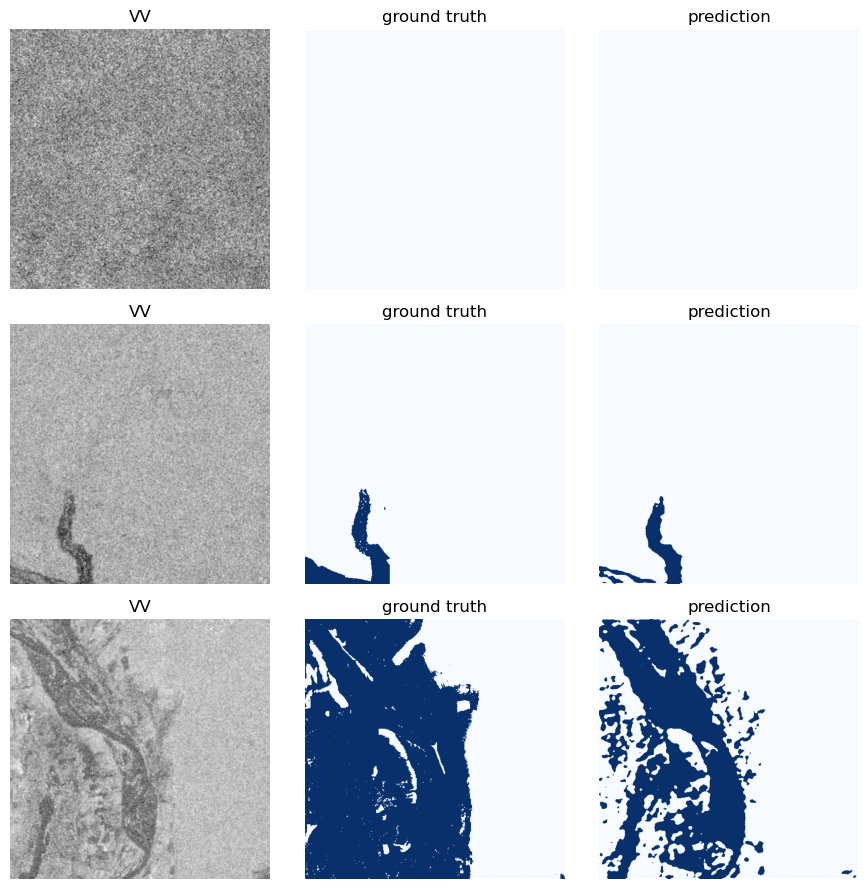

In [10]:
@torch.no_grad()
def show_predictions(dataset, n=3, threshold=0.5):
    model.eval()
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    for i in range(n):
        img, mask, valid = dataset[i]
        logits = model(img.unsqueeze(0).to(device))
        pred = (torch.sigmoid(logits) > threshold).float().cpu()[0, 0]

        axes[i, 0].imshow(img[0], cmap="gray")
        axes[i, 0].set_title("VV")
        axes[i, 1].imshow(mask[0], cmap="Blues")
        axes[i, 1].set_title("ground truth")
        axes[i, 2].imshow(pred, cmap="Blues")
        axes[i, 2].set_title("prediction")
        for ax in axes[i]:
            ax.axis("off")
    plt.tight_layout()
    plt.show()


show_predictions(val_ds)

## Ideas to try next

All of these are single-variable changes in the cells above:
- **Threshold**: sweep `evaluate(val_dl, threshold=x)` over a range instead of guessing 0.5
- **Loss balance**: change `bce_weight` in `bce_dice_loss`
- **Augmentation**: toggle `augment=True/False` on `train_ds`
- **Backbone**: change `encoder_name` in the model cell (e.g. `resnet50`, `efficientnet-b0`)
- **More/less data**: change `MAX_SAMPLES`
- **Training length**: change `EPOCHS`, add early stopping manually if needed

try train_ds augment=False

Add sif11 Hand/water
Group norm instead of batch
CE + Lovasz loss

model = prithvi

run on Bolivia test set

